# MySQL aur Python Connection

In [2]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn=mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='resumeProjectEcommerce'
)

cursor = conn.cursor()

# Company total Sales

In [3]:

query = """
SELECT SUM(o.quantity * p.price) AS company_total_sale
FROM orders o
JOIN products p
ON o.product_id = p.product_id
"""

cursor.execute(query)

data = cursor.fetchall()

df = pd.DataFrame(data, columns=["company_total_sale"])

print(df)

  company_total_sale
0       137355303.00


# Total Revenue Of Company

In [4]:

query = """
SELECT SUM(o.quantity * p.price) AS company_total_sale
FROM orders o
JOIN products p
ON o.product_id = p.product_id
"""

cursor.execute(query)

data = cursor.fetchall()
print("Total Revenue Of Company: ",data[0][0])

Total Revenue Of Company:  137355303.00


# Top 10 highest seller products

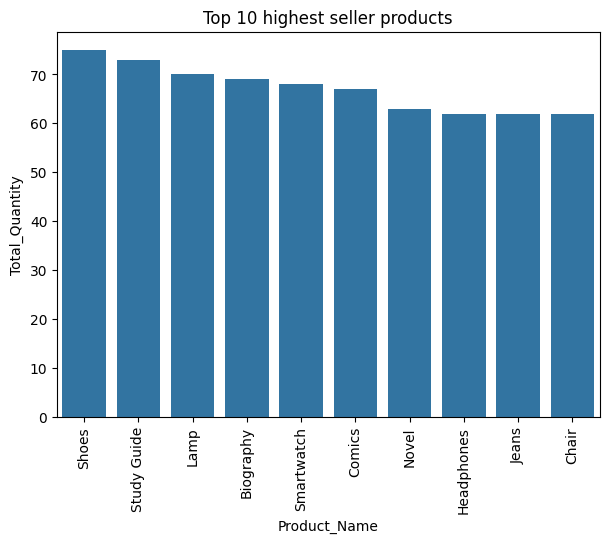

In [17]:
query="""
select p.product_name, count(o.quantity) as total_quantity
from products p
join orders o
on p.product_id=o.product_id
group by p.product_name
order by total_quantity desc
limit 10
"""

cursor.execute(query)

data = cursor.fetchall()
df=pd.DataFrame(data, columns=['Product_Name', 'Total_Quantity'])

plt.figure(figsize=(7, 5))
sns.barplot(x='Product_Name', y='Total_Quantity', data=df)
plt.title('Top 10 highest seller products')
plt.xticks(rotation=90)
plt.savefig('top_10_highest_selling_product.png')
plt.show()

df.to_csv('top_10_highest_selling_product.csv', index=False)

# Which does City most shopping

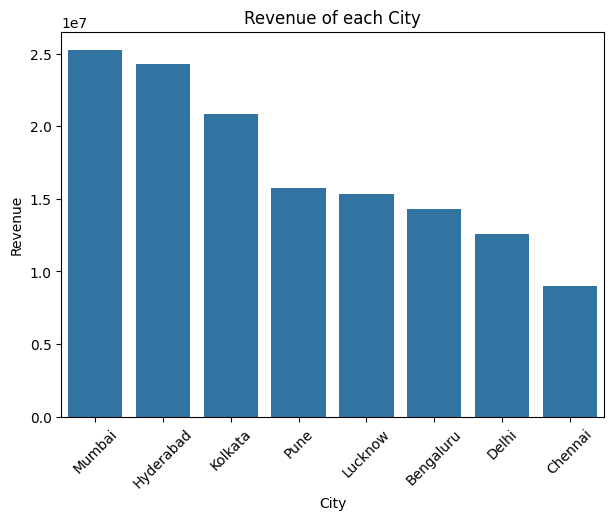

In [18]:
query="""select c.city, SUM(o.quantity*p.price) AS revenue
FROM customers c
JOIN orders o
ON c.customer_id=o.customer_id
JOIN products p
ON p.product_id=o.product_id
GROUP BY c.city
ORDER BY revenue DESC
"""

cursor.execute(query)

data=cursor.fetchall()
df=pd.DataFrame(data, columns=['City', 'Revenue'])

plt.figure(figsize=(7, 5))
sns.barplot(x='City', y='Revenue', data=df)
plt.title('Revenue of each City')
plt.xticks(rotation=45)
plt.savefig('revenue_of_each_city.png')
plt.show()

df.to_csv('city_most_shopping.csv', index=False)

# Monthly Sales Trend Analysis 

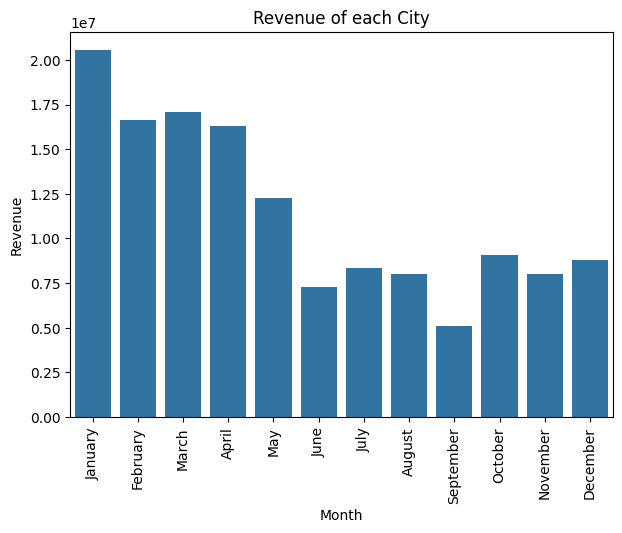

CSV Report Exported Successfully


In [19]:
query="""
select MONTHNAME(o.order_date) AS Month, SUM(o.quantity*p.price) AS Revenue
FROM orders o
JOIN products p
ON o.product_id=p.product_id
GROUP BY Month
"""

cursor.execute(query)
data=cursor.fetchall()
df=pd.DataFrame(data, columns=['Month', 'Revenue'])
o=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(7, 5))
sns.barplot(x='Month', y='Revenue', data=df, order=o)
plt.title('Revenue of each City')
plt.xticks(rotation=90)
plt.savefig('monthly_trend_analysis.png')
plt.show()

df.to_csv('monthly_sales_report.csv', index=False)

print("CSV Report Exported Successfully")

# Customer Analysis: Active Customers

In [8]:
query="""
SELECT 
    c.customer_name, COUNT(o.order_id) AS active_customer
FROM
    customers c
        JOIN
    orders o ON c.customer_id = o.customer_id
GROUP BY customer_name
ORDER BY active_customer DESC
LIMIT 1
"""

cursor.execute(query)
data=cursor.fetchall()
print('Most Active Customer is')
print(f"{data[0][0]}: {data[0][1]}")

Most Active Customer is
Taimur Rama: 18


# Customer Analysis: Higher Spender

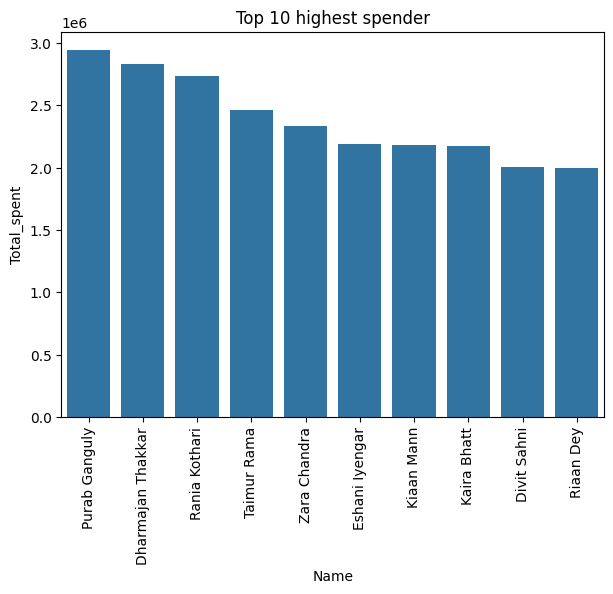

Successfully exported


In [20]:
query="""
SELECT 
    c.customer_name, SUM(o.quantity * p.price) AS total_spent
FROM
    customers c
        JOIN
    orders o ON c.customer_id = o.customer_id
        JOIN
    products p ON o.product_id = p.product_id
GROUP BY c.customer_name
ORDER BY total_spent DESC
LIMIT 10
"""

cursor.execute(query)

data=cursor.fetchall()
df=pd.DataFrame(data, columns=['Name', 'Total_spent'])

plt.figure(figsize=(7, 5))
sns.barplot(x='Name', y='Total_spent', data=df)
plt.title('Top 10 highest spender')
plt.xticks(rotation=90)
plt.savefig('top_10_highest_spender.png')
plt.show()

df.to_csv('top_10_higher_spender.csv', index=False)
print("Successfully exported")

# Customer Analysis: top 10 Average customer spending

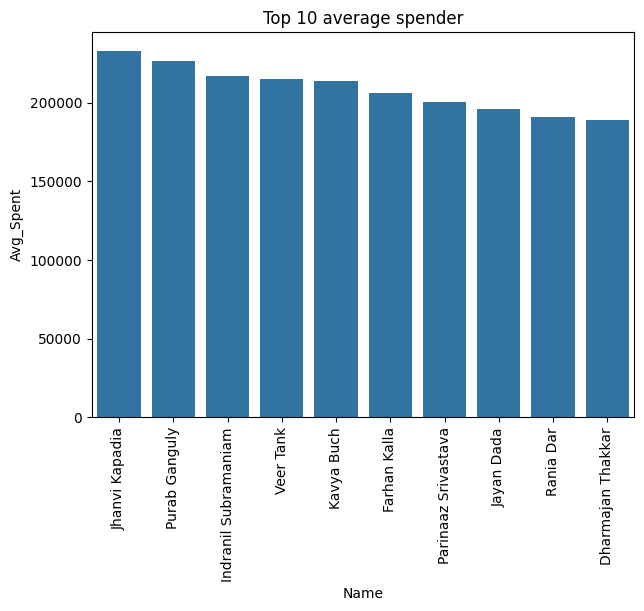

In [21]:
query="""
SELECT 
    c.customer_name, AVG(o.quantity * p.price) AS avg_spent
FROM
    customers c
        JOIN
    orders o ON c.customer_id = o.customer_id
        JOIN
    products p ON o.product_id = p.product_id
GROUP BY c.customer_name
ORDER BY avg_spent DESC
LIMIT 10
"""

cursor.execute(query)

data=cursor.fetchall()
df=pd.DataFrame(data, columns=['Name', 'Avg_Spent'])

plt.figure(figsize=(7, 5))
sns.barplot(x='Name', y='Avg_Spent', data=df)
plt.title('Top 10 average spender')
plt.xticks(rotation=90)
plt.savefig('top_10_average_spender.png')
plt.show()

df.to_csv('top_10_average_spender.csv', index=False)